In [1]:
import librosa # audio loading and feature extraction
import numpy as np# numerical arrays
import pandas as pd # dataframes
import matplotlib.pyplot as plt # plots
import os

In [2]:
DATASET_PATH = r"C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original"
N_MFCC = 20

In [12]:
def mfcc(file, n_mfcc=N_MFCC):
    """
    Extract MFCC features from an audio file.
    Returns the concatenation of mean and standard deviation
    of each MFCC coefficient across time frames
    """

    try:
        audio, sample_rate = librosa.load(file)
    except Exception as e:
        print(f"Skipping {file} due to load error: {e}")
        return None

    mfcc_matrix = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)

    mfcc_mean = np.mean(mfcc_matrix.T, axis=0)   # shape: (n_mfcc,)
    mfcc_std  = np.std(mfcc_matrix.T, axis=0)    # shape: (n_mfcc,)

    mfcc_features = np.concatenate([mfcc_mean, mfcc_std])

    return mfcc_features

In [3]:
def mfcc_delta(file, n_mfcc=N_MFCC):
    """
    Extract MFCC + delta features from an audio file.
    Returns:
    [mfcc_mean, mfcc_std, delta_mean, delta_std]
    """

    try:
        audio, sample_rate = librosa.load(file, sr=None)
    except Exception as e:
        print(f"Skipping {file} due to load error: {e}")
        return None

    try:
        mfcc_matrix = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=n_mfcc
        )

        delta_matrix = librosa.feature.delta(mfcc_matrix)

        mfcc_mean = np.mean(mfcc_matrix, axis=1)
        mfcc_std = np.std(mfcc_matrix, axis=1)

        delta_mean = np.mean(delta_matrix, axis=1)
        delta_std = np.std(delta_matrix, axis=1)

        features = np.concatenate([
            mfcc_mean,
            mfcc_std,
            delta_mean,
            delta_std
        ])

        return features

    except Exception as e:
        print(f"Skipping {file} due to feature extraction error: {e}")
        return None

In [13]:

def load_data(dataset_path=DATASET_PATH,
              n_mfcc=N_MFCC,
              segment_duration=None,
              overlap_duration=0.0):
    """
    Load the dataset and extract features and labels.

    It goes through each genre folder, and for each audio file,
    it extracts MFCC-based features and stores them together with
    the corresponding genre labels.

    Parameters
    ----------
    segment_duration : float or None
        If None, each file is processed as a whole.
        If a number (e.g. 10.0), each audio file is split into
        fixed-length segments.

    overlap_duration : float
        Overlap between consecutive segments in seconds.
        Example:
        segment_duration=10.0, overlap_duration=2.0
        -> segments like 0-10, 8-18, 16-26, ...
        Default is 0.0 (no overlap).
    """

    features = []
    labels = []

    for genre in os.listdir(dataset_path):
        genre_path = os.path.join(dataset_path, genre)

        if not os.path.isdir(genre_path):
            continue

        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)

            if not file_path.endswith(".wav"):
                continue

            # Whole file as one sample
            if segment_duration is None:
                mfcc_features = mfcc(file_path, n_mfcc=n_mfcc)    # case of delta_matrix

                if mfcc_features is None:
                    continue

                features.append(mfcc_features)
                labels.append(genre)

            # Segmentation mode with overlapping
            else:
                try:
                    audio, sample_rate = librosa.load(file_path, sr=None)
                except Exception as e:
                    print(f"Skipping {file_path} due to load error: {e}")
                    continue

                samples_per_segment = int(sample_rate * segment_duration)
                samples_overlap = int(sample_rate * overlap_duration)
                step = samples_per_segment - samples_overlap

                if step <= 0:
                    raise ValueError("overlap_duration must be smaller than segment_duration")

                if len(audio) < samples_per_segment:
                    continue

                for start in range(0, len(audio) - samples_per_segment + 1, step):
                    end = start + samples_per_segment
                    segment = audio[start:end]

                    mfcc_matrix = librosa.feature.mfcc(
                        y=segment,
                        sr=sample_rate,
                        n_mfcc=n_mfcc
                    )

                    #delta_matrix = librosa.feature.delta(mfcc_matrix)

                    mfcc_mean = np.mean(mfcc_matrix.T, axis=1)
                    mfcc_std = np.std(mfcc_matrix.T, axis=1)

                    #delta_mean = np.mean(delta_matrix, axis=1)  # case of delta_matrix
                    #delta_std = np.std(delta_matrix, axis=1)   # case of delta_matrix



                    mfcc_features = np.concatenate([mfcc_mean, mfcc_std]) # case of delta_matrix: , delta_mean, delta_std

                    features.append(mfcc_features)
                    labels.append(genre)

    return np.array(features), np.array(labels)

In [14]:
# Load the dataset and print some information about it to check if its working well

X, y = load_data(segment_duration=10, overlap_duration=2)

print("Feature matrix shape:", X.shape)
print("Label array shape:", y.shape)
print("Genres found:", np.unique(y))



C:\Users\User\AppData\Local\Temp\ipykernel_4960\2766911370.py:55: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_path, sr=None)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original\jazz\jazz.00054.wav due to load error: 
Feature matrix shape: (2997, 862)
Label array shape: (2997,)
Genres found: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


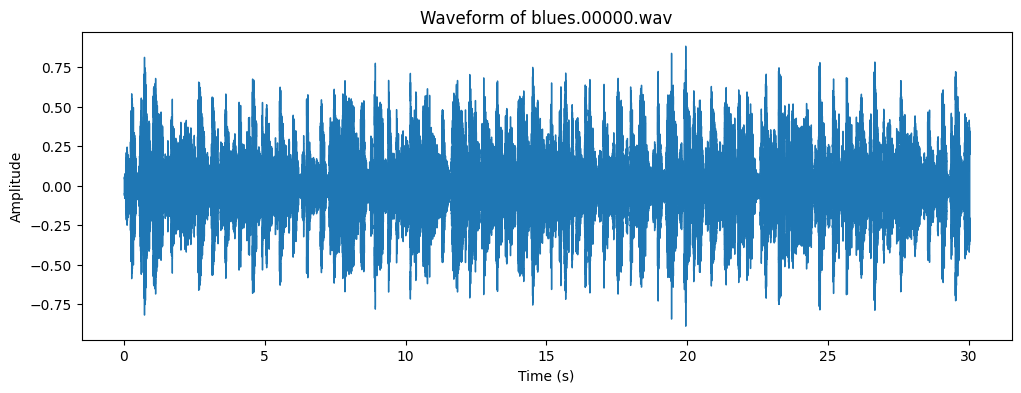

In [8]:
# Plotting the first audio file's waveform and MFCC heatmap for visualization

sample_file = os.path.join(DATASET_PATH, "blues", "blues.00000.wav")

audio, sample_rate = librosa.load(sample_file)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Waveform of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

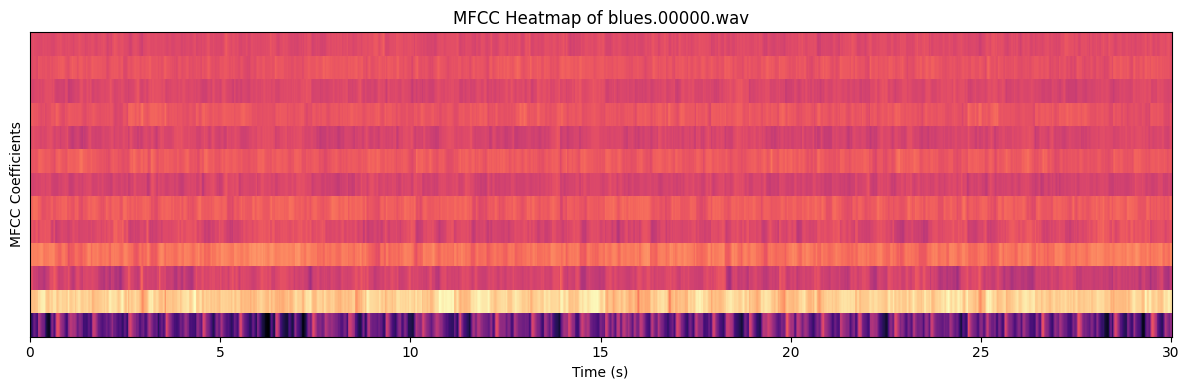

In [196]:
# Extract MFCC features for the sample file

mfcc_matrix = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=N_MFCC)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc_matrix, x_axis='time', sr=sample_rate, cmap='magma')
plt.title("MFCC Heatmap of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()

In [15]:
# Encode labels
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Scale features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42,stratify=y_encoded)


In [16]:
# Train K-NN
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance') 
# use n_neighbors=7, because as it grows, it reduces the variance of the model, but it can also increase bias, so it can be tuned further
# instead of 'uniform' values, to give more weight to closer neighbors
# use manhattan distance instead of euclidean, as it can perform better in high-dimensional spaces
knn.fit(X_train, y_train)

# Evaluate
y_pred_knn = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))



Accuracy: 33.00%
              precision    recall  f1-score   support

       blues       0.25      0.33      0.29        60
   classical       0.45      0.83      0.58        60
     country       0.19      0.07      0.10        60
       disco       0.73      0.18      0.29        60
      hiphop       0.37      0.12      0.18        60
        jazz       0.35      0.37      0.36        60
       metal       0.26      0.88      0.40        60
         pop       0.59      0.17      0.26        60
      reggae       0.83      0.08      0.15        60
        rock       0.25      0.27      0.26        60

    accuracy                           0.33       600
   macro avg       0.43      0.33      0.29       600
weighted avg       0.43      0.33      0.29       600



In [11]:
# Train Random Forest for testing another model, to compare results with K-NN
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 44.33%
              precision    recall  f1-score   support

       blues       0.32      0.27      0.29        60
   classical       0.62      0.83      0.71        60
     country       0.31      0.15      0.20        60
       disco       0.42      0.28      0.34        60
      hiphop       0.36      0.32      0.34        60
        jazz       0.42      0.47      0.44        60
       metal       0.54      0.73      0.62        60
         pop       0.48      0.68      0.57        60
      reggae       0.50      0.48      0.49        60
        rock       0.24      0.22      0.23        60

    accuracy                           0.44       600
   macro avg       0.42      0.44      0.42       600
weighted avg       0.42      0.44      0.42       600



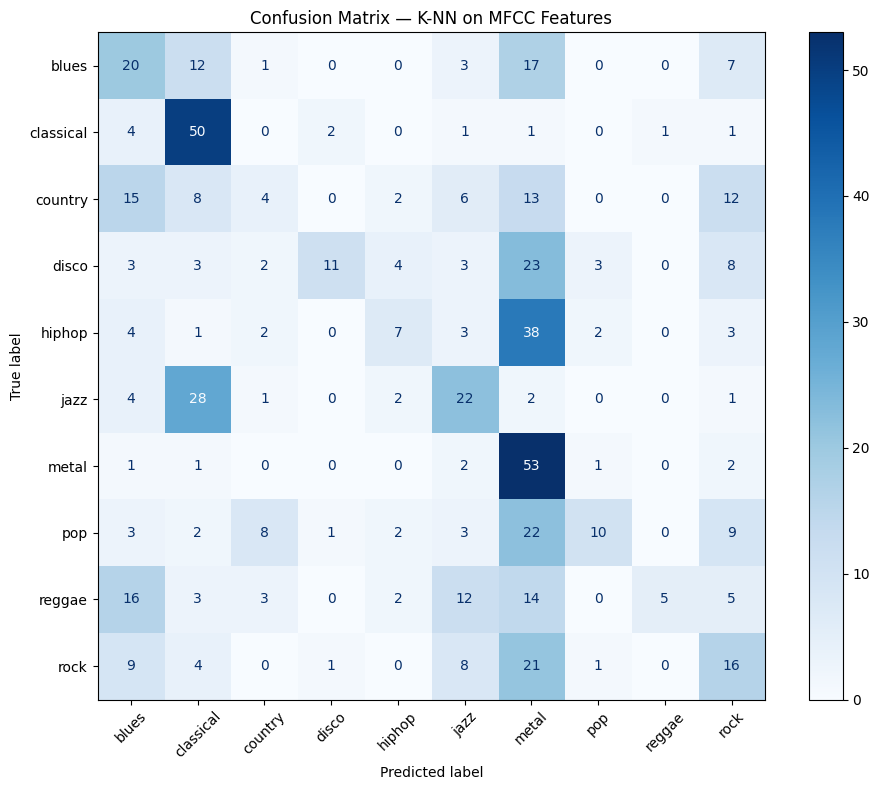

In [17]:
# Confusion matrix for K-NN

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — K-NN on MFCC Features")
plt.tight_layout()
plt.show()

In [ ]:
def predict_genre(file_path,
                  model=knn,
                  label_encoder=label_encoder,
                  scaler=scaler,
                  n_mfcc=N_MFCC,
                  segment_duration=15):
    """
    Predict genre by averaging predictions over multiple segments of a WAV file
    """

    # Load the audio file
    try:
        audio, sample_rate = librosa.load(file_path)
    except Exception as e:
        print(f"Could not load file: {e}")
        return

    # Cut into segments
    samples_per_segment = int(sample_rate * segment_duration)
    n_segments = len(audio) // samples_per_segment


    segments = [audio[i * samples_per_segment : (i + 1) * samples_per_segment] for i in range(n_segments)]

    # Every segment MFCC feature extraction and prediction
    predictions = []

    for segment in segments:
        mfcc_matrix = librosa.feature.mfcc(y=segment, sr=sample_rate, n_mfcc=n_mfcc)

        mfcc_mean = np.mean(mfcc_matrix.T, axis=0)
        mfcc_std  = np.std(mfcc_matrix.T, axis=0)
        features  = np.concatenate([mfcc_mean, mfcc_std])

        # Scaling with the same scaler used during training
        features_scaled = scaler.transform(features.reshape(1, -1))

        # Prediction
        pred = model.predict(features_scaled)[0]
        predictions.append(pred)

    # Majority vote
    final_prediction = max(set(predictions), key=predictions.count)
    genre = label_encoder.inverse_transform([final_prediction])[0]

    # Information about the process
    print(f"Segments analyzed: {n_segments}")
    votes = {
        label_encoder.inverse_transform([p])[0]: predictions.count(p)
        for p in set(predictions)
    }
    
    print(f"Votes per genre: {votes}")
    print(f"Predicted genre: {genre}")

    return genre

In [11]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Another Brick in the Wall.wav")

Segments analyzed: 15
Votes per genre: {np.str_('country'): 1, np.str_('hiphop'): 6, np.str_('metal'): 1, np.str_('pop'): 2, np.str_('reggae'): 5}
Predicted genre: hiphop


np.str_('hiphop')

In [40]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Another Brick in the Wall.wav", model=rf)

Segments analyzed: 15
Votes per genre: {np.str_('classical'): 1, np.str_('country'): 1, np.str_('hiphop'): 1, np.str_('jazz'): 1, np.str_('pop'): 1, np.str_('reggae'): 10}
Predicted genre: reggae


np.str_('reggae')

In [41]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\AC DC Highway to hell.wav", model=rf)

Segments analyzed: 13
Votes per genre: {np.str_('country'): 3, np.str_('disco'): 2, np.str_('jazz'): 2, np.str_('pop'): 4, np.str_('rock'): 2}
Predicted genre: pop


np.str_('pop')

In [42]:
# prediction with the kNN model
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Anastacia - I'm outta love.wav", model=rf )

Segments analyzed: 15
Votes per genre: {np.str_('blues'): 1, np.str_('hiphop'): 1, np.str_('pop'): 13}
Predicted genre: pop


np.str_('pop')

In [43]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Belga - Nemzeti hip hop.wav", model=knn)


Segments analyzed: 21
Votes per genre: {np.str_('blues'): 2, np.str_('classical'): 4, np.str_('country'): 7, np.str_('disco'): 2, np.str_('hiphop'): 1, np.str_('reggae'): 2, np.str_('rock'): 3}
Predicted genre: country


np.str_('country')

In [44]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Belga - Nemzeti hip hop.wav", model=rf)

Segments analyzed: 21
Votes per genre: {np.str_('blues'): 1, np.str_('classical'): 6, np.str_('country'): 10, np.str_('jazz'): 4}
Predicted genre: country


np.str_('country')

In [48]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Bon_Jovi_-_You_give_love_a_bad_name.wav", model=knn)

Segments analyzed: 15
Votes per genre: {np.str_('country'): 1, np.str_('disco'): 1, np.str_('hiphop'): 1, np.str_('jazz'): 4, np.str_('rock'): 8}
Predicted genre: rock


np.str_('rock')

In [47]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Journey - Don't Stop Believin'.wav", model=knn)

Segments analyzed: 16
Votes per genre: {np.str_('classical'): 3, np.str_('country'): 1, np.str_('disco'): 3, np.str_('jazz'): 1, np.str_('rock'): 8}
Predicted genre: rock


np.str_('rock')

In [ ]:
    # real-time genre prediction

    # tsne

    # hugging phase

    # small noise

    # fourier
